# Gradient Boosting

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor
from sklearn.metrics import accuracy_score

In [10]:
df = load_breast_cancer()
X = df.data
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9429824561403509


In [5]:
gb = GradientBoostingClassifier()
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth': [3,5,7]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))


Best Parameters:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}

Best CV Accuracy:
95.9


In [11]:
# Problem 2: Titanic Survival Prediction
import seaborn as sns 
import numpy as np
import pandas as pd 

df = sns.load_dataset('titanic')

# impute missing values using knn imputers in age
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])

# impute embarked missing values using pandas
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
# drop deck column
df.drop('deck', axis=1, inplace=True)

# df missing values
df.isnull().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [12]:
# convert each category column to category
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# add this as a new column in the dataframe
df[categorical_cols] = df[categorical_cols].astype('category')

from sklearn.preprocessing import LabelEncoder


for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

C:\Users\BAHU Computers\AppData\Local\Temp\ipykernel_7560\71400582.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


In [13]:
X = df.drop(['survived','alive','alone'],axis=1)
y = df['survived']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
gb.feature_importances_

Accuracy: 0.8379888268156425


array([0.11745624, 0.00553418, 0.07597516, 0.01181565, 0.00993319,
       0.21167202, 0.00435339, 0.06530778, 0.00130288, 0.48823409,
       0.00841543])

In [ ]:
gb = GradientBoostingClassifier()
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth': [3,5,7]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))


Best Parameters:
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}

Best CV Accuracy:
82.86


In [20]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [26]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

print(r2)
print(mse)

0.7756446042829697
0.2939973248643864


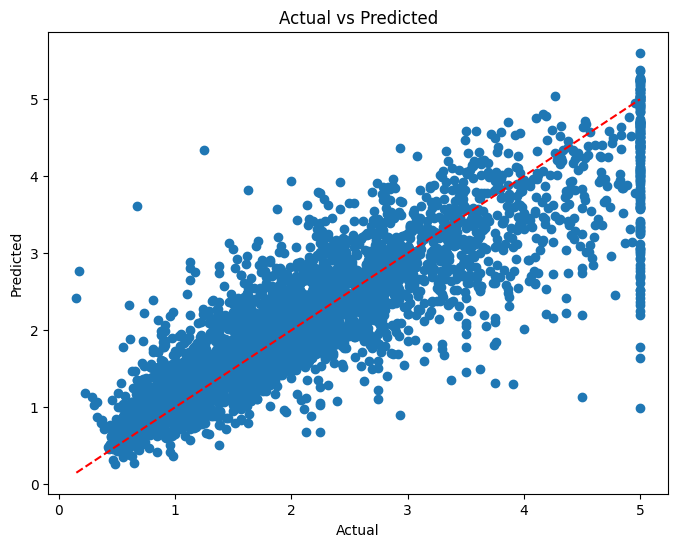

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [33]:
params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))

c:\Users\BAHU Computers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

Best CV Accuracy:
nan


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test)

print("R2 Score :", round(r2_score(y_test, y_pred), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred), 4))
print("MSE      :", round(mean_squared_error(y_test, y_pred), 4))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

R2 Score : 0.3442
MAE      : 0.7292
MSE      : 0.8594
RMSE     : 0.927


# XGBoost

In [2]:
!pip install xgboost

^C


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [2]:
import sys

print(sys.version)
print(sys.executable)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
c:\Users\BAHU Computers\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [4]:
df = pd.read_csv('./Datasets/customer_churn_data.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CUST5875,Male,0,Yes,Yes,71,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,74.21,5268.91,No
5876,CUST5876,Male,0,No,No,22,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,One year,No,Mailed check,65.43,1439.46,Yes
5877,CUST5877,Female,0,No,No,68,No,No phone service,Fiber optic,Yes,...,Yes,Yes,Yes,No,One year,Yes,Bank transfer,59.78,4065.04,No
5878,CUST5878,Female,0,Yes,Yes,14,No,No phone service,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,91.88,1286.32,No


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data = ["gender", "Churn", "PaperlessBilling", "Contract","PhoneService","Dependents","Partner","OnlineSecurity","TechSupport","InternetService","PaymentMethod"]
for col in data:
    df[col] = le.fit_transform(df[col])

X = df[['gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService','Contract','PaperlessBilling','MonthlyCharges','TotalCharges',"OnlineSecurity","TechSupport","InternetService","PaymentMethod"]]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [9]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5051020408163265

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      1196
           1       0.50      0.44      0.47      1156

    accuracy                           0.51      2352
   macro avg       0.50      0.50      0.50      2352
weighted avg       0.50      0.51      0.50      2352



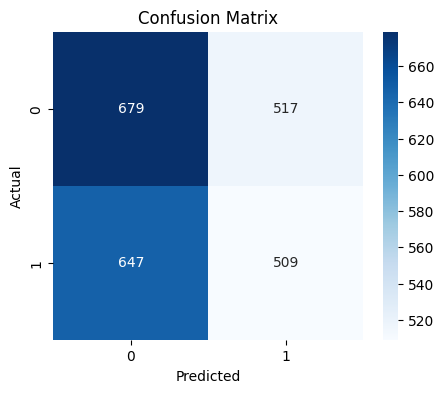

In [11]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

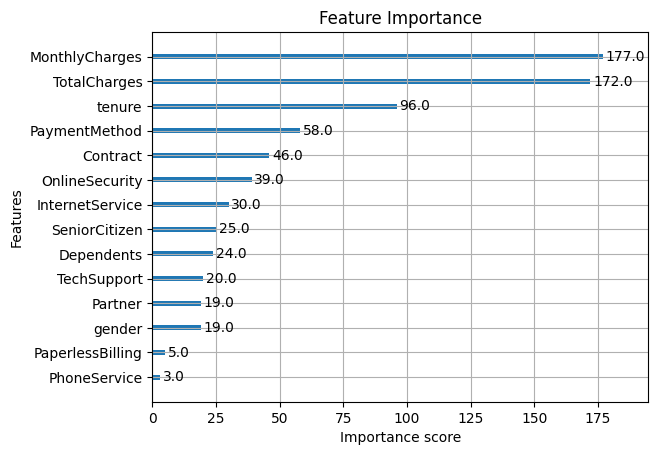

In [12]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

In [13]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [15]:
model = XGBClassifier(objective='binary:logistic',
    max_depth = 4,
    learning_rate= 0.1,
    n_estimators=100,
    alpha=10)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9333333333333333

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.81      0.89        21
           2       0.87      1.00      0.93        20

    accuracy                           0.93        60
   macro avg       0.94      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



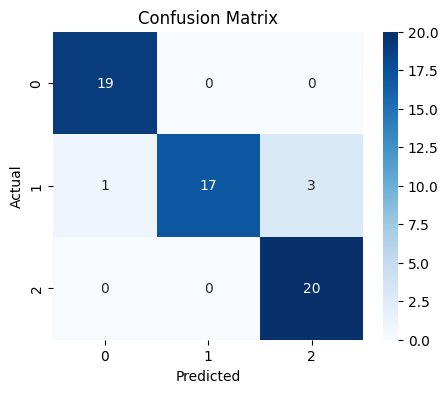

In [17]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {
    'n_estimators':[50,100],
    'learning_rate':[0.01,0.1],
    'max_depth':[2,3,4]
}
model = XGBClassifier(objective='binary:logistic')

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))

# =========================
# PREDICTIONS
# =========================

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

# =========================
# ACCURACY
# =========================

train_acc = accuracy_score(
    y_train,
    train_pred
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("\nTrain Accuracy:", round(train_acc * 100, 2))
print("Test Accuracy :", round(test_acc * 100, 2))

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred
    )
)

# =========================
# CONFUSION MATRIX
# =========================

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred
    )
)



Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

Best CV Accuracy:
92.22

Train Accuracy: 97.78
Test Accuracy : 96.67

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.95      1.00      0.98        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60


Confusion Matrix:
[[19  0  0]
 [ 1 19  1]
 [ 0  0 20]]


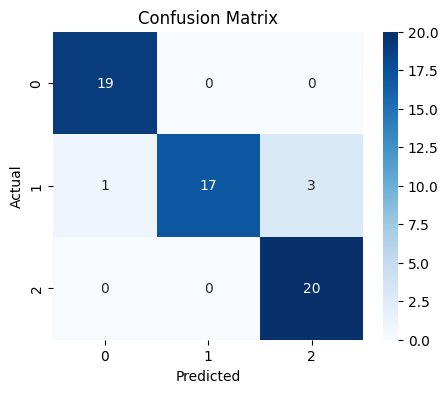

In [20]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()